<a href="https://colab.research.google.com/github/sulucay01/multimodal-rs-segmentation/blob/dev/notebooks/06_qualitative_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06 — Qualitative Analysis and Progression

DI725 Term Project — Multimodal Fusion for Remote Sensing Land Cover Segmentation

This notebook shows how the segmentation improves across three stages of the project. It loads predictions already saved by the experimental notebooks, so no model runs here.

The difference between the stages is what the model is allowed to see. The first stage uses the image alone. The next two stages are multimodal: they also receive a caption describing the scene and use it as an extra input alongside the image, so the caption can guide the prediction.

The three stages, in order:

1. **Vision-only:** UNetFormer using the RGB image alone. No caption. Saved as `vision_only_masks.npy` by nb03.
2. **Multimodal (CLIP):** The same UNetFormer, made multimodal by adding a frozen CLIP text encoder. The `text_qwen3-4b` caption is encoded and passed into the decoder through gated cross-attention, so the prediction uses both the image and the caption. Trained with weighted cross-entropy. Saved as `multimodal_baseline_masks.npy` by nb04.
3. **Multimodal (RemoteCLIP + CE+Dice):** The same multimodal design, with two changes: the text encoder is RemoteCLIP, pretrained on remote sensing image-text pairs, instead of CLIP, and the loss is CE+Dice instead of weighted cross-entropy. This is the final configuration. Saved as `phase3_best_masks.npy` by nb05.

All three are evaluated on the same unshuffled test split, so a given row index refers to the same scene in every array.

Sections:

1. Setup
2. Load predictions and inputs
3. One worked example
4. Where each step helps
5. Worst cases
6. Per-class performance
7. Summary

## 1. Setup

In [ ]:
# Mount Google Drive to access the project data and saved predictions.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imports
import json
import textwrap
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [ ]:
# Paths. Predictions, captions, and result JSONs all live on Drive,
# written by the earlier notebooks.
PROJECT_DIR     = Path('/content/drive/MyDrive/DI725_Project')
DATA_DIR        = PROJECT_DIR / 'data'
IMAGES_DIR      = DATA_DIR / 'images'
MASKS_CLASS_DIR = DATA_DIR / 'masks_class'      # class-index masks, values 0 to 6
SPLITS_CSV      = DATA_DIR / 'captions_with_splits.csv'
PREDICTIONS_DIR = PROJECT_DIR / 'predictions'
RESULTS_DIR     = PROJECT_DIR / 'results'

for p in [IMAGES_DIR, MASKS_CLASS_DIR, SPLITS_CSV, PREDICTIONS_DIR, RESULTS_DIR]:
    assert p.exists(), f'Missing expected path: {p}'
print('All paths found.')

All paths found.


In [ ]:
# Classes and the color palette, identical to nb01.
CLASS_NAMES = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
NUM_CLASSES = len(CLASS_NAMES)

CLASS_RGB = {
    'Tree':     (0,   100, 0),
    'Shrub':    (255, 182, 193),
    'Grass':    (154, 205, 50),
    'Crop':     (255, 215, 0),
    'Built-up': (139, 69,  19),
    'Barren':   (211, 211, 211),
    'Water':    (0,   0,   255),
}

# (7, 3) uint8 palette so an index mask colorizes by PALETTE[mask].
PALETTE = np.array([CLASS_RGB[c] for c in CLASS_NAMES], dtype=np.uint8)
CLASS_COLORS = [np.array(CLASS_RGB[c]) / 255.0 for c in CLASS_NAMES]
LEGEND_HANDLES = [Patch(facecolor=CLASS_COLORS[i], edgecolor='gray', label=CLASS_NAMES[i])
                  for i in range(NUM_CLASSES)]
print('Palette ready.')

Palette ready.


In [ ]:
# Reference test mIoU for each stage, read from the saved result JSONs.
# Shown here as orientation before the figures, and reused for the consistency
# check in Section 6.
with open(RESULTS_DIR / 'baselines_results.json') as f:
    vision_json = json.load(f)
with open(RESULTS_DIR / 'multimodal_results.json') as f:
    clip_json = json.load(f)
with open(RESULTS_DIR / 'additivity_check.json') as f:
    remoteclip_json = json.load(f)

CAPTION_COL = 'text_qwen3-4b'

REF_MIOU = {
    'vision_only': vision_json['unetformer']['test_miou'],
    'clip':        clip_json['multimodal'][CAPTION_COL]['test_miou'],
    'remoteclip':  remoteclip_json['combined']['test_miou'],
}

STAGE_LABELS = {
    'vision_only': 'Vision-only',
    'clip':        'Multimodal (CLIP)',
    'remoteclip':  'Multimodal (RemoteCLIP + CE+Dice)',
}

print(f"{'Stage':<34}{'test mIoU':>11}")
print('-' * 45)
for key in ['vision_only', 'clip', 'remoteclip']:
    print(f"{STAGE_LABELS[key]:<34}{REF_MIOU[key]:>11.4f}")

Stage                               test mIoU
---------------------------------------------
Vision-only                            0.6488
Multimodal (CLIP)                      0.6970
Multimodal (RemoteCLIP + CE+Dice)      0.7347


## 2. Load predictions and inputs

The three prediction arrays were saved by nb03, nb04, and nb05 over the same unshuffled test split, so they share one row order. `test_filenames.csv`, written by nb03, is the canonical order and maps each row to its image, ground-truth mask, and caption.

In [ ]:
# Canonical test order and the three prediction arrays, keyed by stage.
filenames = pd.read_csv(PREDICTIONS_DIR / 'test_filenames.csv')['filename'].tolist()
N = len(filenames)

PREDS = {
    'vision_only': np.load(PREDICTIONS_DIR / 'vision_only_masks.npy'),
    'clip':        np.load(PREDICTIONS_DIR / 'multimodal_baseline_masks.npy'),
    'remoteclip':  np.load(PREDICTIONS_DIR / 'phase3_best_masks.npy'),
}

print(f'Test images (from test_filenames.csv): {N}')
for key in ['vision_only', 'clip', 'remoteclip']:
    arr = PREDS[key]
    print(f'  {STAGE_LABELS[key]:<34} {arr.shape}  dtype={arr.dtype}  classes={np.unique(arr)}')

Test images (from test_filenames.csv): 1500
  Vision-only                        (1500, 256, 256)  dtype=uint8  classes=[0 1 2 3 4 5 6]
  Multimodal (CLIP)                  (1500, 256, 256)  dtype=uint8  classes=[0 1 2 3 4 5 6]
  Multimodal (RemoteCLIP + CE+Dice)  (1500, 256, 256)  dtype=uint8  classes=[0 1 2 3 4 5 6]


In [ ]:
# Alignment checks. Each array must match the filename count, share the same
# spatial size, and contain only valid class indices.
ref_shape = PREDS['vision_only'].shape
for key, arr in PREDS.items():
    assert arr.shape[0] == N, f'{key}: {arr.shape[0]} preds vs {N} filenames'
    assert arr.shape[1:] == ref_shape[1:], f'{key}: spatial size mismatch'
    assert arr.min() >= 0 and arr.max() < NUM_CLASSES, f'{key}: class index out of range'

H, W = ref_shape[1:]
print('All prediction arrays aligned and valid.')
print(f'Mask size: {H} x {W}')

All prediction arrays aligned and valid.
Mask size: 256 x 256


In [ ]:
# Copy the test ground-truth masks to local SSD once, then load them into memory.
# Reading from /content avoids the Drive I/O bottleneck. Only the test masks are
# copied, so the copy stays small. The guard skips files already copied.
PROGRESS_INTERVAL = 250  # print progress every this many masks while loading

LOCAL_MASKS_CLASS = Path('/content/masks_class')
LOCAL_MASKS_CLASS.mkdir(parents=True, exist_ok=True)

print('Copying test masks to local SSD...')
copied = 0
for fname in filenames:
    dst = LOCAL_MASKS_CLASS / fname
    if not dst.exists():
        shutil.copy(MASKS_CLASS_DIR / fname, dst)
        copied += 1
print(f'Copied {copied} masks ({N - copied} already present).')

# Load the test ground-truth class masks once, in the canonical order.
gt_masks = np.zeros((N, H, W), dtype=np.uint8)
for i, fname in enumerate(filenames):
    gt_masks[i] = np.array(Image.open(LOCAL_MASKS_CLASS / fname))
    if (i + 1) % PROGRESS_INTERVAL == 0:
        print(f'  loaded {i + 1}/{N}')

assert gt_masks.min() >= 0 and gt_masks.max() < NUM_CLASSES, 'GT class index out of range'
print(f'Ground-truth masks loaded: {gt_masks.shape}')

Copying test masks to local SSD...
Copied 1500 masks (0 already present).
  loaded 250/1500
  loaded 500/1500
  loaded 750/1500
  loaded 1000/1500
  loaded 1250/1500
  loaded 1500/1500
Ground-truth masks loaded: (1500, 256, 256)


In [ ]:
# Captions the multimodal stages received, keyed by filename.
# Both multimodal stages use the text_qwen3-4b column. Vision-only uses no caption.
caption_df = pd.read_csv(SPLITS_CSV)
captions_map = dict(zip(caption_df['filename'], caption_df[CAPTION_COL].astype(str)))

missing = [f for f in filenames if f not in captions_map]
assert not missing, f'{len(missing)} test filenames have no caption'
print(f'Captions loaded for {len(captions_map)} images. Example:')
print(f'  {filenames[0]}: {captions_map[filenames[0]][:120]}')

Captions loaded for 10000 images. Example:
  0312.png: The scene is predominantly agricultural, with 70% covered by crops, indicating a large-scale farming area. Small patches


## 3. One worked example

Before any aggregate numbers, here is a single scene followed end to end: the input image, the caption the multimodal stages received, the ground truth, and the prediction from each stage. This sets expectations for what goes in and what comes out, and shows the per-image mIoU rising as the caption is added and the encoder and loss are upgraded.

In [ ]:
# Helpers for colorizing masks, scoring one image, and reading one input image.
def colorize(mask):
    """Map a (H, W) class-index mask to an (H, W, 3) RGB image via the palette."""
    return PALETTE[mask]

def per_image_miou(pred, gt, num_classes=NUM_CLASSES):
    """Mean IoU for one image, averaged over classes present in pred or gt.
    Classes absent from both are excluded, matching the project mIoU convention."""
    ious = []
    for c in range(num_classes):
        p = pred == c
        g = gt == c
        union = (p | g).sum()
        if union == 0:
            continue
        ious.append((p & g).sum() / union)
    return float(np.mean(ious)) if ious else 0.0

def load_image(fname):
    """Read one input RGB image from Drive for display."""
    return np.array(Image.open(IMAGES_DIR / fname).convert('RGB'))

print('Helpers ready.')

Helpers ready.


In [ ]:
# Per-image mIoU for every stage, used for annotation and for selecting scenes.
scores = {
    key: np.array([per_image_miou(PREDS[key][i], gt_masks[i]) for i in range(N)])
    for key in PREDS
}
print('Per-image mIoU computed.')
for key in ['vision_only', 'clip', 'remoteclip']:
    print(f'  mean per-image mIoU, {STAGE_LABELS[key]:<34} {scores[key].mean():.4f}')

Per-image mIoU computed.
  mean per-image mIoU, Vision-only                        0.4208
  mean per-image mIoU, Multimodal (CLIP)                  0.4662
  mean per-image mIoU, Multimodal (RemoteCLIP + CE+Dice)  0.4904


In [ ]:
# Panel function. Each scene renders as its own figure: input, ground truth, then
# the stage predictions named in `stages`. Each prediction carries its per-image
# mIoU. show_caption adds the caption strip, border frames the scene, and each
# figure gets its own legend.
STAGE_TITLE = {
    'vision_only': 'Vision-only',
    'clip':        'Multimodal (CLIP)',
    'remoteclip':  'Multimodal\n(RemoteCLIP + CE+Dice)',
}

def _draw_scene(axes_row, idx, stages):
    """Fill a row of axes: input, ground truth, then one panel per stage in `stages`."""
    images = [load_image(filenames[idx]), colorize(gt_masks[idx])]
    titles = ['Input', 'Ground truth']
    keys   = [None, None]
    for s in stages:
        images.append(colorize(PREDS[s][idx]))
        titles.append(STAGE_TITLE[s])
        keys.append(s)
    for ax, img, title, key in zip(axes_row, images, titles, keys):
        ax.imshow(img)
        ax.axis('off')
        if key is not None:
            title = f'{title}\nmIoU {scores[key][idx]:.3f}'
        ax.set_title(title, fontsize=10)

def _show_one(idx, stages, show_caption, border=False):
    """Render a single scene as its own figure, with its own class legend."""
    ncols = 2 + len(stages)
    if show_caption:
        fig = plt.figure(figsize=(3.0 * ncols, 4.6))
        gs = fig.add_gridspec(2, ncols, height_ratios=[6, 1.4], hspace=0.05, wspace=0.05,
                              left=0.02, right=0.98, top=0.82, bottom=0.14)
    else:
        fig = plt.figure(figsize=(3.0 * ncols, 3.8))
        gs = fig.add_gridspec(1, ncols, wspace=0.05, left=0.02, right=0.98,
                              top=0.82, bottom=0.14)

    axes_row = [fig.add_subplot(gs[0, c]) for c in range(ncols)]
    _draw_scene(axes_row, idx, stages)

    if show_caption:
        cap_ax = fig.add_subplot(gs[1, :])
        cap_ax.axis('off')
        cap_ax.text(0.5, 1.0,
                    'Caption given to the multimodal stages '
                    '(Vision-only uses no caption):',
                    transform=cap_ax.transAxes, ha='center', va='top',
                    fontsize=8, style='italic', color='gray')
        wrapped = textwrap.fill(captions_map[filenames[idx]], width=110)
        cap_ax.text(0.5, 0.55, wrapped, transform=cap_ax.transAxes,
                    ha='center', va='top', fontsize=9)

    fig.legend(handles=LEGEND_HANDLES, loc='lower center', ncol=NUM_CLASSES,
               bbox_to_anchor=(0.5, 0.05), fontsize=9)

    if border:
        rect = plt.Rectangle((0.01, 0.04), 0.98, 0.92, transform=fig.transFigure,
                             fill=False, edgecolor='0.5', linewidth=1.5)
        fig.add_artist(rect)
    plt.show()

def show_panels(indices, stages=('vision_only', 'clip', 'remoteclip'),
                show_caption=False, border=False):
    """Render each scene as its own figure showing the given stages."""
    for idx in indices:
        _show_one(idx, list(stages), show_caption, border=border)

print('Panel function ready.')

Panel function ready.


Worked example: 177512.png
Classes present: Tree, Shrub, Grass, Crop, Built-up, Barren

Per-image mIoU across stages:
  Vision-only                        0.352
  Multimodal (CLIP)                  0.432
  Multimodal (RemoteCLIP + CE+Dice)  0.549

Caption given to the multimodal stages:
The scene is predominantly forested, with tree cover accounting for 75% of the land use,
indicating a heavily wooded area. Grasslands make up a smaller portion, with minimal
built-up areas.


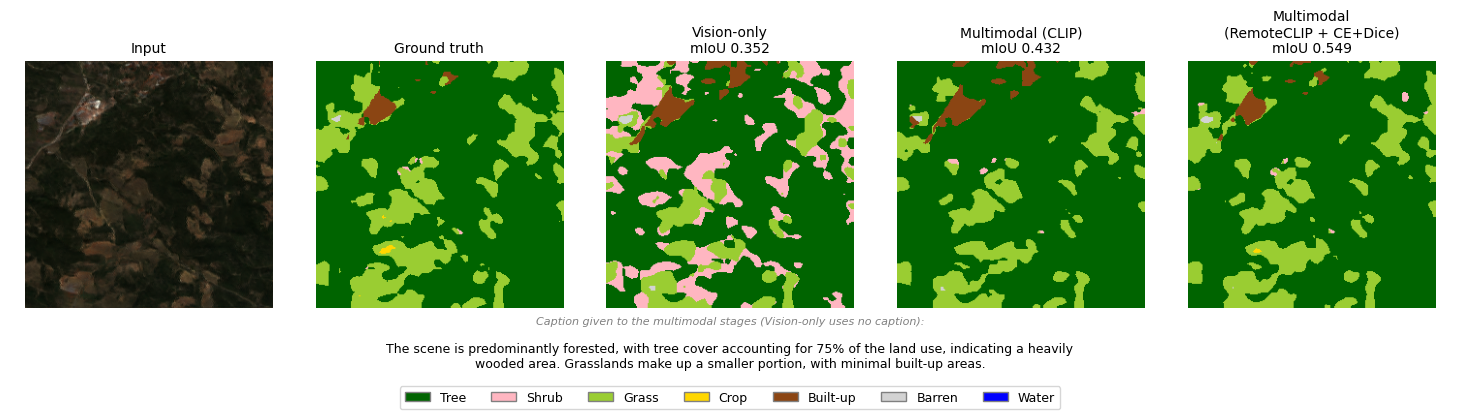

In [ ]:
# Pick one clear teaching scene where every stage strictly improves on the one
# before, by at least a small margin, so the worked example shows real gains at
# each step rather than a single jump. Among those, prefer a crowded scene (more
# classes) with the largest total gain.
MARGIN = 0.05  # minimum per-step mIoU gain to count as an improvement

step1 = scores['clip']       - scores['vision_only']   # Vision-only -> CLIP
step2 = scores['remoteclip'] - scores['clip']          # CLIP -> RemoteCLIP
num_classes_present = np.array([len(np.unique(gt_masks[i])) for i in range(N)])

strictly_improving = (step1 >= MARGIN) & (step2 >= MARGIN)
candidates = np.where(strictly_improving)[0]
assert len(candidates) > 0, 'No scene improves at every stage by the margin; lower MARGIN.'

# Among strictly improving scenes, rank by class count then total gain, so the
# chosen scene is both crowded and clearly progressing.
total_gain = scores['remoteclip'] - scores['vision_only']
example_idx = int(max(candidates,
                      key=lambda i: (num_classes_present[i], total_gain[i])))

print(f'Worked example: {filenames[example_idx]}')
print(f'Classes present: {", ".join(CLASS_NAMES[c] for c in np.unique(gt_masks[example_idx]))}')
print()
print('Per-image mIoU across stages:')
for key in ['vision_only', 'clip', 'remoteclip']:
    print(f'  {STAGE_LABELS[key]:<34} {scores[key][example_idx]:.3f}')
print()
print('Caption given to the multimodal stages:')
print(textwrap.fill(captions_map[filenames[example_idx]], width=88))

show_panels([example_idx], show_caption=True)

**Observations:** Per-image mIoU rises at each stage on this scene: 0.352 (Vision-only), 0.432 (CLIP), 0.549 (RemoteCLIP + CE+Dice). The Vision-only prediction scatters Shrub widely through the forest and over-grows the Built-up patch. Adding the caption removes most of the spurious Shrub and tightens the Built-up region. The final stage refines the boundaries further and recovers more of the Grass patches against the surrounding Tree.

The caption describes the scene as predominantly forested with a smaller grassland portion and minimal built-up area. The progression tracks that description: the noisy Shrub and oversized Built-up of the image-only prediction move toward a Tree-dominant map with contained Grass and Built-up. The Crop recovery at the final stage (0.00 to 0.29) is not from the caption, which never mentions Crop. It comes from the encoder-or-loss change, most likely the CE+Dice loss recovering a small under-predicted class.

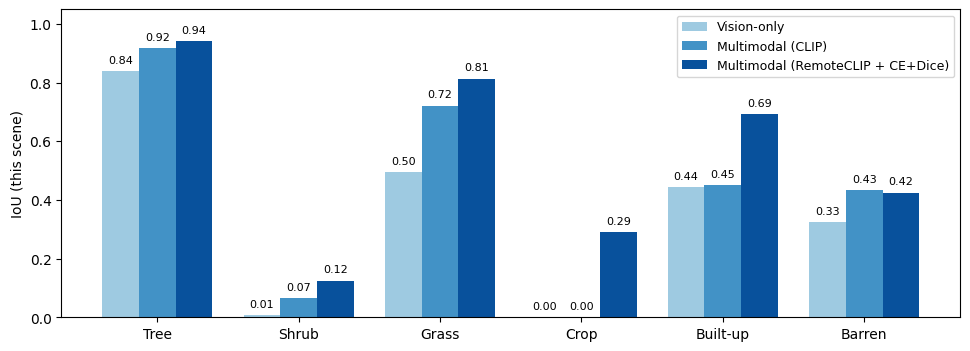

In [ ]:
# Per-class IoU for the worked-example scene, one group per class, three stage
# bars per group. This shows which class each stage actually improved, where the
# single per-image mIoU only shows the total. These are single-image IoUs for
# this one scene, not the dataset per-class IoU reported in Section 6.
def per_class_iou_single(pred, gt, num_classes=NUM_CLASSES):
    """Per-class IoU for one image. NaN where the class is absent from pred and gt."""
    out = []
    for c in range(num_classes):
        p = pred == c
        g = gt == c
        union = (p | g).sum()
        out.append((p & g).sum() / union if union > 0 else np.nan)
    return out

# Classes present in this scene's ground truth, in canonical class order.
present = [c for c in range(NUM_CLASSES) if c in np.unique(gt_masks[example_idx])]
present_names = [CLASS_NAMES[c] for c in present]

stage_keys = ['vision_only', 'clip', 'remoteclip']
iou_by_stage = {
    key: per_class_iou_single(PREDS[key][example_idx], gt_masks[example_idx])
    for key in stage_keys
}

# Grouped bars: x is class, three bars per class for the three stages.
x = np.arange(len(present))
width = 0.26
# Distinct shades so the three stages read left to right within each class group.
stage_bar_colors = ['#9ecae1', '#4292c6', '#08519c']

fig, ax = plt.subplots(figsize=(1.6 * len(present) + 2, 4))
for s, key in enumerate(stage_keys):
    vals = [iou_by_stage[key][c] for c in present]
    bars = ax.bar(x + (s - 1) * width, vals, width,
                  color=stage_bar_colors[s], label=STAGE_LABELS[key])
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f'{v:.2f}',
                    ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(present_names)
ax.set_ylabel('IoU (this scene)')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9, loc='upper right')
plt.show()

**Observations:** Per-class IoU on this scene increases or holds for every class across the three stages. The largest moves are Grass (0.50, 0.72, 0.81) and Built-up (0.44, 0.45, 0.69), with Built-up gaining mainly at the final stage. Crop is 0.00 at the Vision-only and CLIP stages and 0.29 at the final stage. Tree is high throughout (0.84, 0.92, 0.94). Shrub stays the lowest class at every stage (0.01, 0.07, 0.12).

The two steps contribute to different classes here. Adding the caption drives most of the Grass gain (0.50 to 0.72), while the encoder-and-loss step drives the Built-up gain (0.45 to 0.69) and the Crop recovery (0.00 to 0.29). Shrub remains low across all three, consistent with it being the hardest class elsewhere in the project.

## 4. Where each step helps

The progression has two steps: adding the caption (Vision-only to CLIP), then upgrading the encoder and loss (CLIP to RemoteCLIP + CE+Dice). This section shows the scenes where each step helps most, three scenes per group. The caption is shown under each row.

In [ ]:
# Per-scene gains for each transition. Each ranking selects the scenes where that
# specific step improved the per-image mIoU most.
gain_vision_to_clip = scores['clip']       - scores['vision_only']   # adding the caption
gain_clip_to_final  = scores['remoteclip'] - scores['clip']          # encoder + loss upgrade

def top_scenes(gain, k=3):
    return np.argsort(gain)[::-1][:k].tolist()

def report(title, gain, idx_list, from_key, to_key):
    print(title)
    for idx in idx_list:
        print(f"  {filenames[idx]:<16} "
              f"{scores[from_key][idx]:.3f} -> {scores[to_key][idx]:.3f} "
              f"(+{gain[idx]:.3f})")
    print()

idx_vc = top_scenes(gain_vision_to_clip)
idx_cf = top_scenes(gain_clip_to_final)

report('Vision-only -> Multimodal (CLIP):',          gain_vision_to_clip, idx_vc, 'vision_only', 'clip')
report('Multimodal (CLIP) -> RemoteCLIP + CE+Dice:', gain_clip_to_final,  idx_cf, 'clip', 'remoteclip')

Vision-only -> Multimodal (CLIP):
  196521.png       0.226 -> 0.901 (+0.676)
  285119.png       0.382 -> 1.000 (+0.618)
  153905.png       0.241 -> 0.783 (+0.541)

Multimodal (CLIP) -> RemoteCLIP + CE+Dice:
  16679.png        0.499 -> 1.000 (+0.501)
  129612.png       0.234 -> 0.647 (+0.413)
  112308.png       0.383 -> 0.766 (+0.383)



### Adding the caption: Vision-only to Multimodal (CLIP)

Scenes where giving the model the caption improved the prediction most.

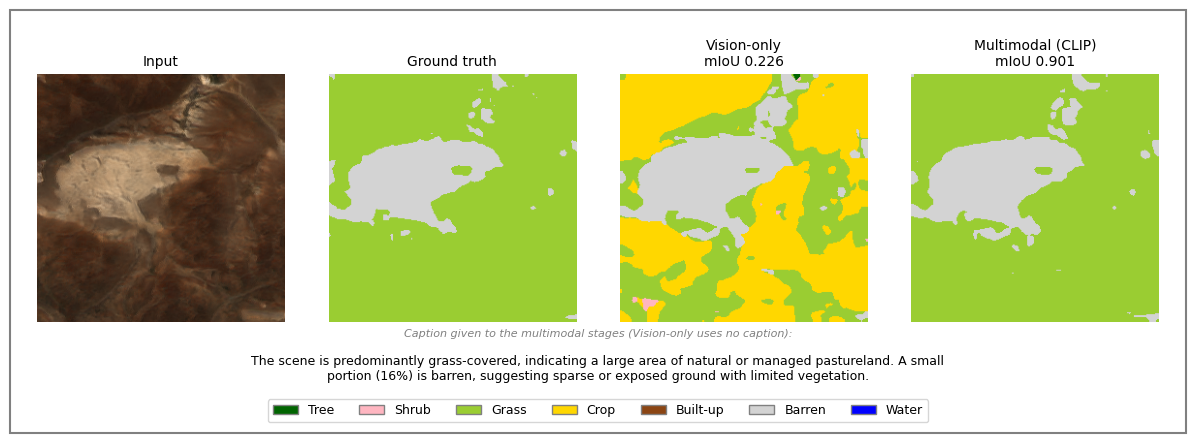

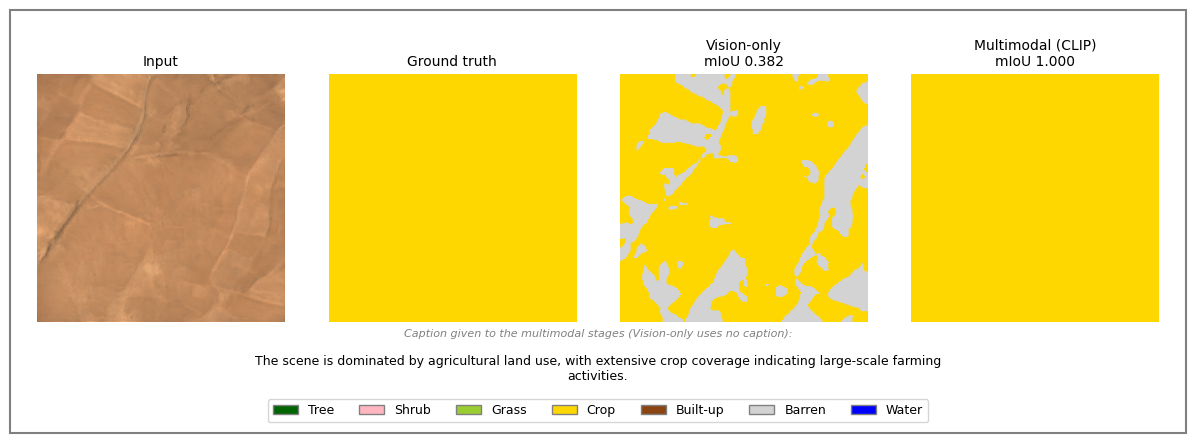

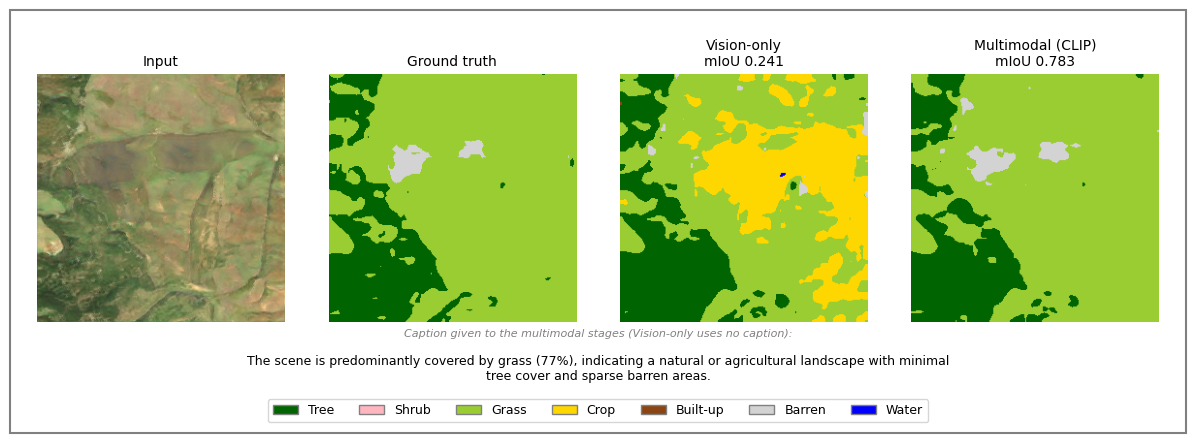

In [ ]:
show_panels(idx_vc, stages=('vision_only', 'clip'), show_caption=True, border=True)

**Observations, per scene:**

Scene 1 (mIoU 0.226 to 0.901): Ground truth is Grass with a central Barren patch. Vision-only labels large areas as Crop and adds scattered Shrub. CLIP removes the Crop, keeps the Grass, and recovers the Barren patch. The caption states the scene is predominantly grass-covered with a small barren portion.

Scene 2 (mIoU 0.382 to 1.000): Ground truth is entirely Crop. Vision-only fragments the field into Crop and large Barren patches. CLIP predicts uniform Crop. The caption states the area is dominated by crop coverage. This is a single-class scene, so the perfect score is an easy case.

Scene 3 (mIoU 0.241 to 0.783): Ground truth is Grass with Tree along the edges. Vision-only fills the center with Crop. CLIP removes the Crop and restores the Grass and Tree layout. The caption states the scene is predominantly grass with minimal tree cover.

Across the three, Vision-only repeatedly predicts Crop on land that is Grass or bare, and the caption naming the dominant class corresponds to CLIP removing that false Crop.

### Upgrading encoder and loss: Multimodal (CLIP) to RemoteCLIP + CE+Dice

Scenes where switching to the RemoteCLIP encoder and the CE+Dice loss improved the prediction most, with the caption held fixed.

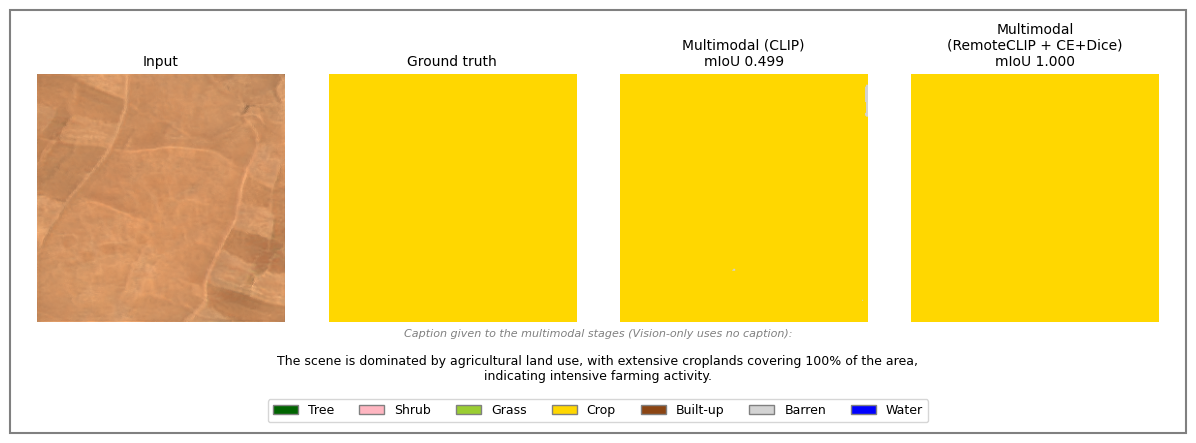

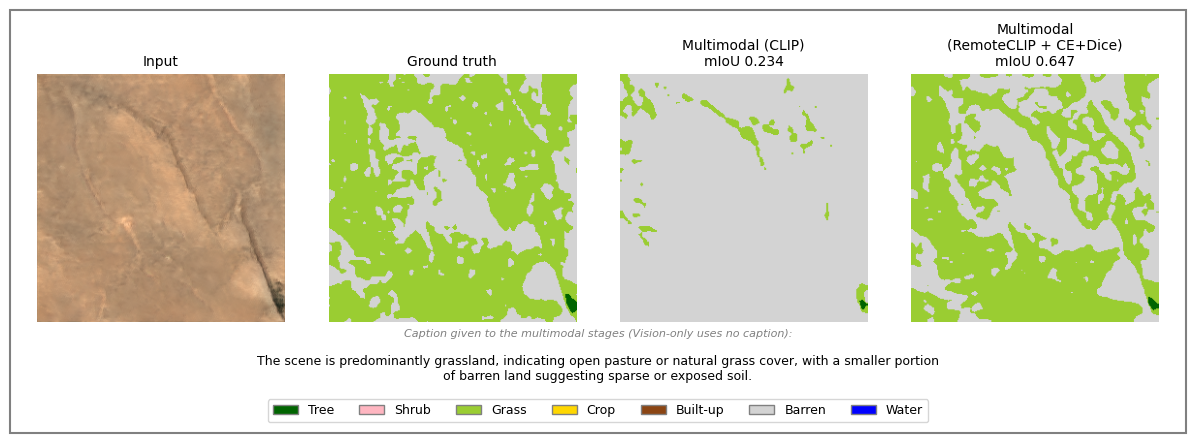

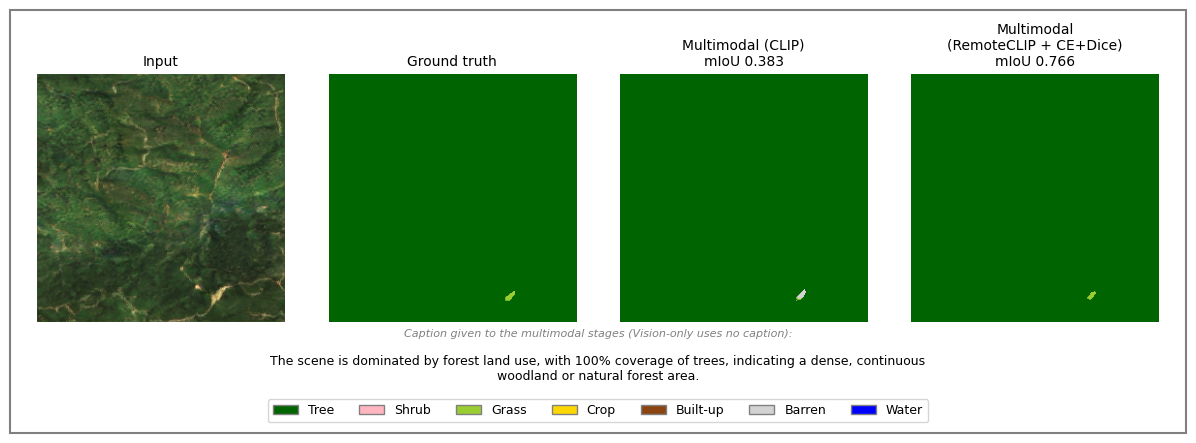

In [ ]:
show_panels(idx_cf, stages=('clip', 'remoteclip'), show_caption=True, border=True)

**Observations, per scene:** The caption is identical between the two stages, so any change comes from the RemoteCLIP encoder and the CE+Dice loss, not the text.

Scene 1 (mIoU 0.499 to 1.000): Ground truth is entirely Crop. CLIP leaves a thin strip along one edge mislabeled. The final stage fills the field uniformly. This is a single-class scene, so the perfect score is an easy case.

Scene 2 (mIoU 0.234 to 0.647): Ground truth is Grass mixed with Barren. CLIP collapses almost the whole scene to Barren and drops most of the Grass. The final stage restores much of the Grass against the Barren.

Scene 3 (mIoU 0.383 to 0.766): Ground truth is Tree across the scene with a small Grass region. Tree is predicted perfectly at both stages. CLIP also predicts a little Barren that is not in the ground truth, scored at 0, which holds its average down. The final stage drops that Barren and improves the Grass region (0.148 to 0.532), which accounts for the gain.

Across the three, the gains do not trace to the caption, which is fixed. They are consistent with the CE+Dice loss improving the dominant-class region, most clearly in scene 2 where the recovered Grass is the bulk of the change.

## 5. Worst cases

This section shows the hardest scenes for the final stage, by lowest per-image mIoU, with the caption shown for each.

Hardest final-stage scenes by per-image mIoU:
  8191.png         mIoU 0.184   classes present: Tree, Grass, Crop, Built-up, Barren, Water
  122275.png       mIoU 0.187   classes present: Tree, Grass, Crop, Built-up, Barren, Water
  161409.png       mIoU 0.187   classes present: Tree, Grass, Barren


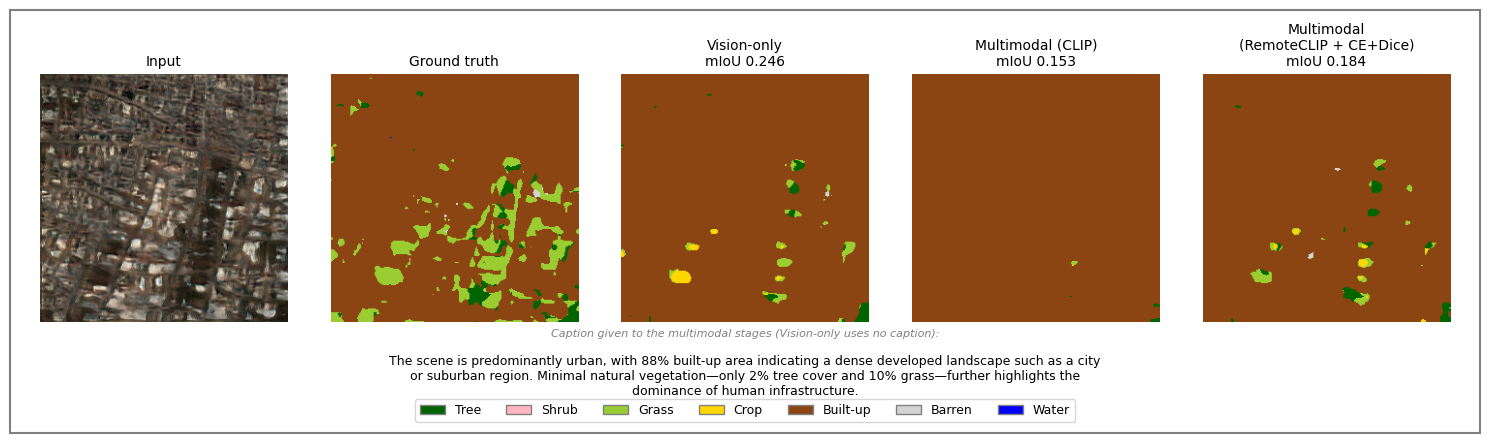

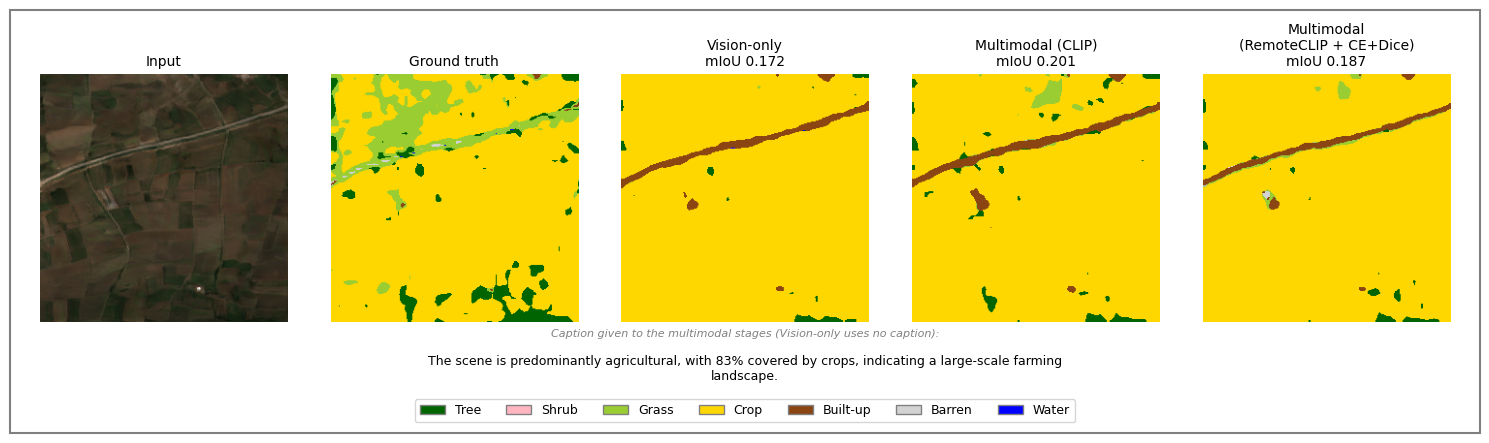

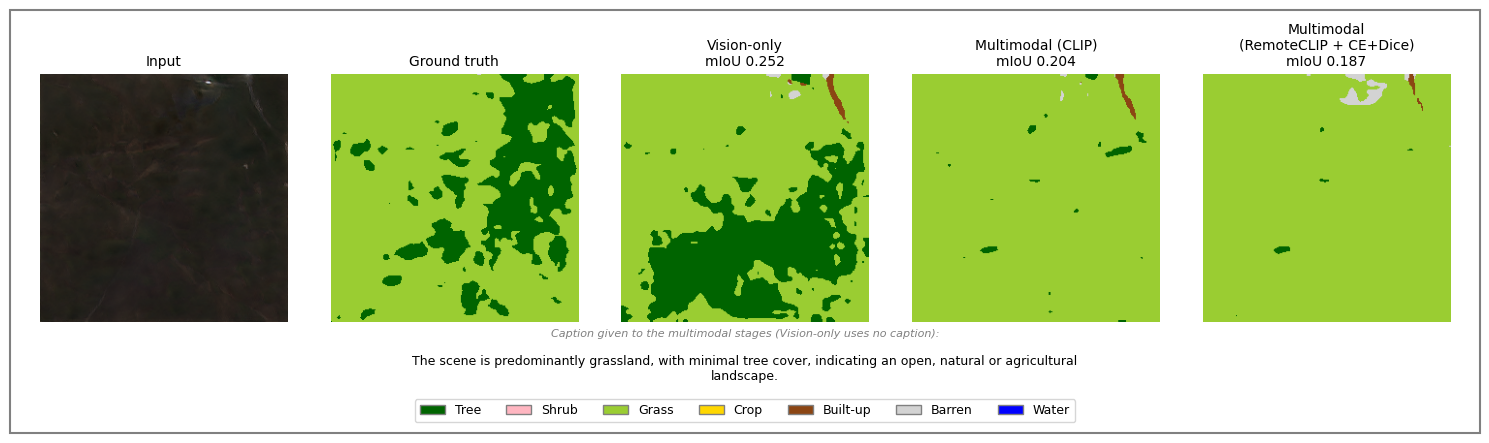

In [ ]:
# Hardest scenes for the final stage, by lowest per-image mIoU, full progression shown.
worst_idx = np.argsort(scores['remoteclip'])[:3].tolist()

print('Hardest final-stage scenes by per-image mIoU:')
for idx in worst_idx:
    present_classes = [CLASS_NAMES[c] for c in np.unique(gt_masks[idx])]
    print(f"  {filenames[idx]:<16} mIoU {scores['remoteclip'][idx]:.3f}   "
          f"classes present: {', '.join(present_classes)}")

show_panels(worst_idx, show_caption=True, border=True)

**Observations, per scene:**

Scene 1: Ground truth is mostly Built-up with small Tree and Grass regions. The dominant Built-up is predicted well at every stage. The low score comes from the small vegetation classes, which all stages miss. The caption mentions the urban setting along with the small Tree and Grass, but naming them was not enough for the model to recover them.

Scene 2: Ground truth is mostly Crop with small Tree and Grass regions and a thin Built-up line. Crop is predicted well throughout. The low score comes from the small Tree and Grass regions, which all stages miss. The caption names only the dominant crop and does not mention the small Tree or Grass, so the text offers nothing to recover them.

Scene 3: This is a dark, low-contrast input. Ground truth is mostly Grass with a substantial Tree portion. Grass is handled reasonably across stages, but the Tree is lost: it is partly captured by Vision-only and almost entirely dropped by the multimodal stages. Here the multimodal stages make a minority class worse rather than better.

Across these, the dominant class is predicted well in every scene, and the low scores come from minority classes. In scene 1 the caption names the small Tree and Grass, but the model still misses them. In scene 2 the caption names only the dominant Crop, so the small classes get no text signal at all. In scene 3 the multimodal stages actively lose the Tree, a case where the caption stage hurts a minority class rather than leaving it unaddressed.

## 6. Per-class performance

This is the per-class IoU of the final stage over the whole test set. It shows which classes carry the score and which hold it back. The recomputed mIoU is checked against the reference saved in `additivity_check.json`, so the figure is confirmed to describe the reported model.

In [ ]:
# Per-class IoU for the final stage over the whole test set, plus a check that
# the recomputed mIoU matches the score reported for this model.
MIOU_TOLERANCE = 1e-3  # acceptable rounding gap vs the saved reference

def pixel_class_iou(stage_key):
    inter = np.zeros(NUM_CLASSES, dtype=np.int64)
    union = np.zeros(NUM_CLASSES, dtype=np.int64)
    preds = PREDS[stage_key]
    for c in range(NUM_CLASSES):
        p = preds == c
        g = gt_masks == c
        inter[c] = (p & g).sum()
        union[c] = (p | g).sum()
    ious = [inter[c] / union[c] if union[c] > 0 else np.nan for c in range(NUM_CLASSES)]
    valid = [x for x in ious if not np.isnan(x)]
    return ious, (float(np.mean(valid)) if valid else 0.0)

final_ious, final_miou = pixel_class_iou('remoteclip')

ref_miou = REF_MIOU['remoteclip']
print(f'Recomputed final-stage mIoU: {final_miou:.4f}')
print(f'Reference (additivity_check.json): {ref_miou:.4f}')
print(f'Difference: {final_miou - ref_miou:+.4f}')
assert abs(final_miou - ref_miou) < MIOU_TOLERANCE, 'Recomputed mIoU does not match the reference.'
print('Matches reference within rounding.')

Recomputed final-stage mIoU: 0.7347
Reference (additivity_check.json): 0.7347
Difference: +0.0000
Matches reference within rounding.


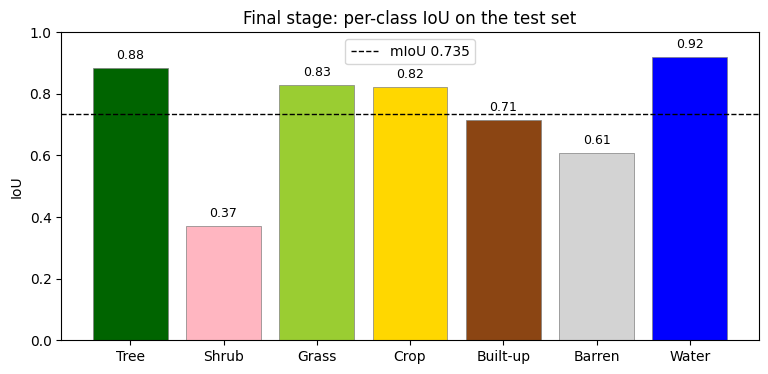

In [ ]:
# Per-class IoU bar chart for the final stage, colored by the class palette.
valid = [not np.isnan(x) for x in final_ious]
names  = [CLASS_NAMES[i]  for i in range(NUM_CLASSES) if valid[i]]
values = [final_ious[i]   for i in range(NUM_CLASSES) if valid[i]]
colors = [CLASS_COLORS[i] for i in range(NUM_CLASSES) if valid[i]]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(names, values, color=colors, edgecolor='gray', linewidth=0.5)
ax.axhline(final_miou, color='black', linestyle='--', linewidth=1,
           label=f'mIoU {final_miou:.3f}')
ax.set_ylabel('IoU')
ax.set_ylim(0, 1)
ax.set_title('Final stage: per-class IoU on the test set')
for bar, value in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.2f}',
            ha='center', va='bottom', fontsize=9)
ax.legend()
plt.show()

**Observations:** Final-stage per-class IoU ranges from 0.37 (Shrub) to 0.92 (Water). Four classes sit above the mIoU of 0.735: Water (0.92), Tree (0.88), Grass (0.83), and Crop (0.82). Built-up (0.71) and Barren (0.61) sit below it, and Shrub (0.37) is well below, about half the next-lowest class.

Shrub is the clear bottleneck on the overall score. Its IoU is far below every other class, which is consistent with it being the rarest class in the dataset and with the per-scene tables, where Shrub stayed low across all stages. The recomputed mIoU matches the reference in additivity_check.json within rounding, confirming these are the predictions behind the reported score.

## 7. Summary

This notebook traced the segmentation across three stages on the test set: Vision-only, Multimodal (CLIP), and Multimodal (RemoteCLIP + CE+Dice).

The caption is the main driver of the improvement. The recurring pattern is that Vision-only predicts Crop on dry or bare terrain that is actually Grass or Barren, and the caption naming the dominant class removes that false Crop. This holds across independent scenes, not just one. The encoder-and-loss upgrade adds smaller, less uniform gains, with one clear case where CLIP collapses a scene to one class and the final stage restores the correct mix.

The overall score is held back by Shrub, which has by far the lowest per-class IoU, consistent with it being the rarest class in the data.

The worst cases show the progression is not uniformly positive. The dominant class is always predicted well, and the low scores come from minority classes, for different reasons: named in the caption but still missed, not named at all, or actively lost by the multimodal stages. Naming a class in the caption does not guarantee its recovery, and the caption can occasionally steer a minority class the wrong way.

Overall, the caption drives most of the gain, the encoder-and-loss step refines it, and the remaining ceiling is rare-class recall rather than the dominant classes.